Merge two CSVs recieved from NLS. Clips_Table which contains the filename and ref no for each video. And FILMS which contains the ref and description for each video.

Save the results in clips_films.csv.

Different descriptive columns are then inspected to understand prevalence of values such as year, type or compilations.

In [1]:
import pandas as pd
from pathlib import Path

metadata_folder = Path('../../data/input/NLS/batch2/NLS Metadata')
clips_films_path = Path('../../data/output/ws1/clips_films.csv')

# Load the CSV files
df_clips = pd.read_csv(metadata_folder / 'Clips_Table.csv', encoding='cp1252')
df_films = pd.read_csv(metadata_folder / 'FILMS.csv', encoding='cp1252')


In [2]:
# Join on a common column (e.g., 'ID')
# Default join type is 'inner', which keeps only matching rows
df_joined = pd.merge(df_clips, df_films, on='ref no')

# Save the result if needed
df_joined.to_csv(clips_films_path, index=False)

df = df_joined

In [3]:
years_freq = df['dateOfReleaseYYYY'].value_counts()
years_freq

dateOfReleaseYYYY
1982    62
1985    34
1984    30
1980    26
1981    26
        ..
1987     1
2002     1
1999     1
2023     1
2016     1
Name: count, Length: 71, dtype: int64

In [4]:
import matplotlib.pyplot as plt

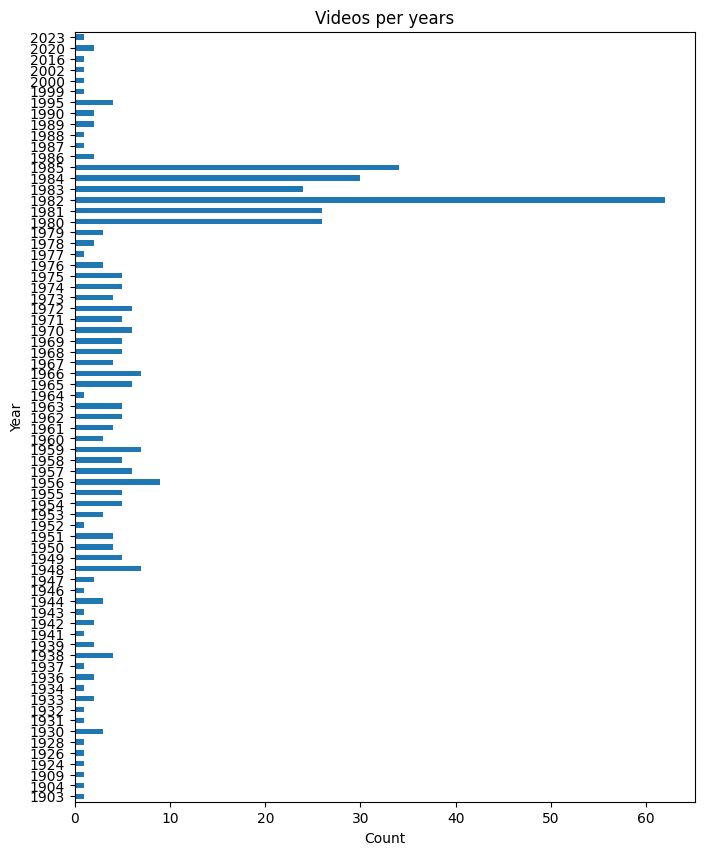

In [5]:
years_freq.sort_index().plot(kind='barh', title='Videos per years', figsize=(8, 10))

plt.ylabel('Year')
plt.xlabel('Count')
# plt.xticks(rotation=0)  # Keep labels horizontal
plt.show()

In [6]:
types_freq = df['type'].str.split(', ').explode().value_counts()
types_freq

type
tv news                    123
tv news                     72
amateur                     59
educational                 35
sponsored                   22
                          ... 
amateur\nlocal topical       1
\nadvertising                1
educational\nscientific      1
comedy\ndrama                1
instructional                1
Name: count, Length: 65, dtype: int64

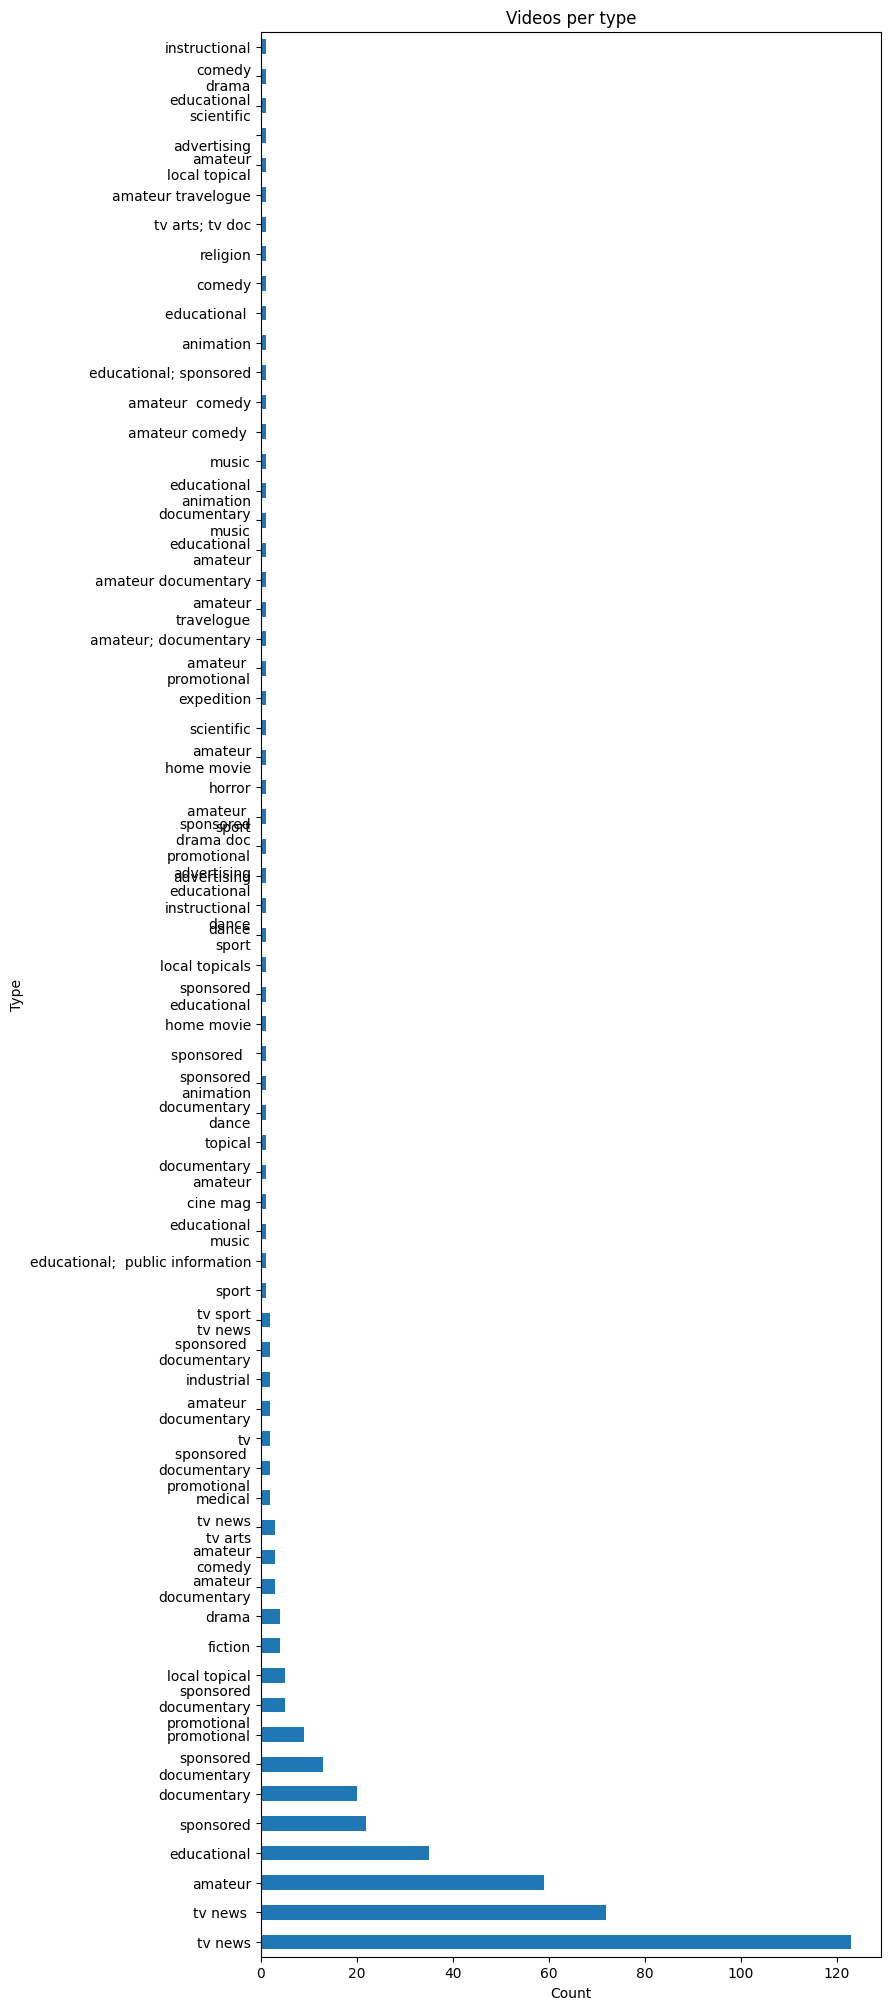

In [7]:
types_freq.plot(kind='barh', title='Videos per type', figsize=(8, 25))

plt.ylabel('Type')
plt.xlabel('Count')
# plt.xticks(rotation=0)  # Keep labels horizontal
plt.show()

In [8]:
silents = df[df['sound'] == 'silent']
silents[['DODfilenameprefix', 'title', 'dateOfReleaseYYYY', 'timing', 'colour', 'type']]


,DODfilenameprefix,title,dateOfReleaseYYYY,timing,colour,type
2,75247299,CANALS IN SCOTLAND,1938,9.30 mins,bw,educational
5,75247337,CRIEFF HIGHLAND GATHERING,1950,16.30 mins,col,amateur
7,75247389,WOOD GOES TO WAR,1943,30.47 mins,col,documentary\namateur
9,76413703,[EDWARD VII LAYS FOUNDATION STONE],1903,2.30 mins,bw,topical
10,77025546,"RIVER TAY, the",1956,10.55 mins,bw,educational
...,...,...,...,...,...,...
380,239343226,"EDINBURGH SCHOOL OF CHIROPODY, the",1938,6.18 mins,bw,sponsored
383,239832473,"1949 SCOTTISH SIX DAYS RELIABILITY TRIAL, the",1949,59.58 mins,col,documentary
394,260522455,(ANTI-GAS PRECAUTIONS IN GLASGOW),1942,10.00 mins,bw,instructional
396,266661940,"GUIDE TO MARRIAGE, a",1958,9.57 mins,col,amateur


In [9]:
compilations = df[df['synopsis'].str.contains('compilation', case=False, na=False)]
compilations[['DODfilenameprefix', 'title', 'dateOfReleaseYYYY', 'timing', 'colour', 'type']]

,DODfilenameprefix,title,dateOfReleaseYYYY,timing,colour,type
13,78295398,FESTIVAL IN EDINBURGH,1955,13.00 mins,col,"sponsored, documentary"
33,85060728,[MAGAZINE - LOOKING BACK],1966,35.49 mins,bwcol,amateur
106,106033956,"(GLASGOW STREET SCENES / ""KILL THE BILL"" DEMON...",1975,21.52 mins,col,amateur
139,139192001,[GRAMPIAN TELEVISION NEWS TAPE L0515],1985,61.10 mins,col,tv news
159,139329403,[GRAMPIAN TELEVISION NEWS TAPE L0032],1980,58.15 mins,col,tv news
...,...,...,...,...,...,...
334,144133866,[GRAMPIAN TELEVISION NEWS TAPE L0851],1989,62.00 mins,col,tv news
335,144133880,[GRAMPIAN TELEVISION NEWS TAPE L0858],1989,50.10 mins,col,tv news
369,234552207,[GRAMPIAN TELEVISION NEWS TAPE L1355],1995,109.49 mins,col,tv news
370,234773769,[GRAMPIAN TELEVISION NEWS TAPE L1345],1995,110:00 mins,col,tv news


In [20]:
from pathlib import Path
import re

sample_file = 'sample-11.txt'
sample_path = Path(sample_file)

samples = sample_path.read_text().split('\n')
samples = [s for s in samples if s and not s.startswith('#')]
sample_filenos = [int(re.sub(r'^.*/(\d+)\.32.*$', r'\1', s)) for s in samples]
sample_filenos


[139329389,
 75247299,
 82814521,
 83972061,
 100194707,
 234552207,
 140833800,
 91174079,
 260522455,
 103008963,
 106033956]

In [24]:
df_samples = df[df['DODfilenameprefix'].isin(sample_filenos)]
df_samples_narrow = df_samples[['DODfilenameprefix', 'title', 'dateOfReleaseYYYY', 'timing', 'colour', 'type', 'synopsis']]
df_samples_narrow.to_csv('sample-11.csv', index=False)
df_samples_narrow

,DODfilenameprefix,title,dateOfReleaseYYYY,timing,colour,type,synopsis
2,75247299,CANALS IN SCOTLAND,1938,9.30 mins,bw,educational,"Scotland's three canals, the Crinan, Caledonia..."
27,82814521,SISYPHUS,1971,3 mins,sepia,sponsored\nanimation,Films of Scotland's first cartoon film. A ver...
29,83972061,LES BETES NOIRES,1962,10.55 mins,col,amateur,Entertaining domestic scenes as the family pup...
45,91174079,CLEAN FOOD,1957,16.04 mins,bw,sponsored,"Public information film taking the form of a ""..."
69,100194707,AMATEUR CINEMATOGRAPHY,1948,3.00 mins,bw,advertising,"Demonstration on how to make a film, made as a..."
92,103008963,ROBOT THREE,1951,12 mins,col,"amateur, fiction, horror",Fictional story following the lines of a Frank...
106,106033956,"(GLASGOW STREET SCENES / ""KILL THE BILL"" DEMON...",1975,21.52 mins,col,amateur,A compilation of amateur film showing places a...
152,139329389,[GRAMPIAN TELEVISION NEWS TAPE L0139],1982,32.12 mins,col,tv news,"Six news items from Grampian Television,"
272,140833800,[GRAMPIAN TELEVISION NEWS TAPE L0337],1984,65.00 mins,col,tv sport\ntv news,"Grampian Television news tape, featuring items..."
369,234552207,[GRAMPIAN TELEVISION NEWS TAPE L1355],1995,109.49 mins,col,tv news,A compilation tape featuring news items from G...
